<a href="https://colab.research.google.com/github/mehaklaha/Machine-Learning-LAB-Repo/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("joebeachcapital/cirrhosis-patient-survival-prediction")

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 11.0k/11.0k [00:00<00:00, 18.0MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/joebeachcapital/cirrhosis-patient-survival-prediction/versions/1
/root/.cache/kagglehub/datasets/joebeachcapital/cirrhosis-patient-survival-prediction/versions/1/cirrhosis.csv


In [4]:
file_path = os.path.join(path, "cirrhosis.csv")  # adjust if needed

df = pd.read_csv(file_path)

df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [6]:
df.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [7]:
np.sum(pd.isnull(df).sum())

np.int64(1033)

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
print(df.columns)

target_col = 'Status_D'  # Changed from 'Status' to 'Status_D'

y = df[target_col]
X = df.drop(target_col, axis=1)

Index(['ID', 'N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage', 'Status_CL', 'Status_D', 'Drug_Placebo', 'Sex_M', 'Ascites_Y',
       'Hepatomegaly_Y', 'Spiders_Y', 'Edema_S', 'Edema_Y'],
      dtype='object')


In [12]:
df['Target'] = y
df.head()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,...,Status_CL,Status_D,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y,Target
0,1,400,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,...,False,True,False,False,True,True,True,False,True,True
1,2,4500,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,...,False,False,False,False,False,True,True,False,False,False
2,3,1012,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,...,False,True,False,True,False,False,False,True,False,True
3,4,1925,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,...,False,True,False,False,False,True,True,True,False,True
4,5,1504,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,...,True,False,True,False,False,True,True,False,False,False


/tmp/ipykernel_331/3238907664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='RdBu_r')


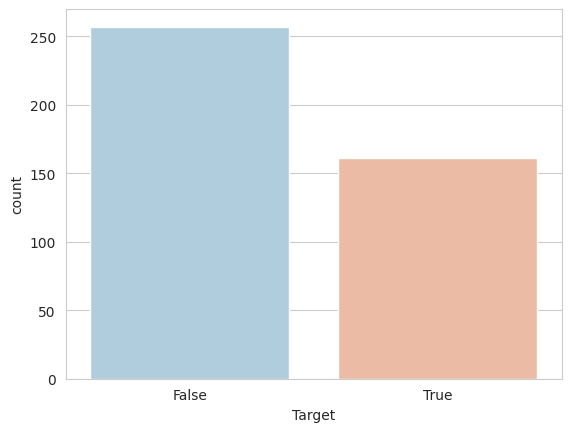

In [13]:
sns.set_style('whitegrid')

sns.countplot(x='Target', data=df, palette='RdBu_r')
plt.show()

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


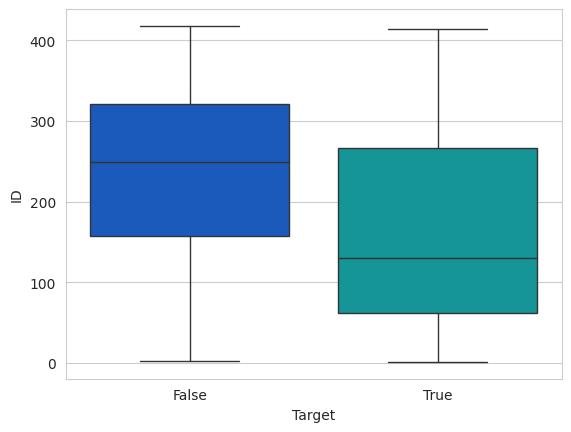

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


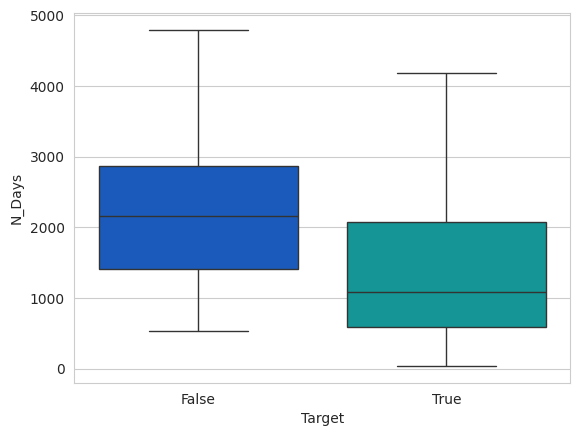

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


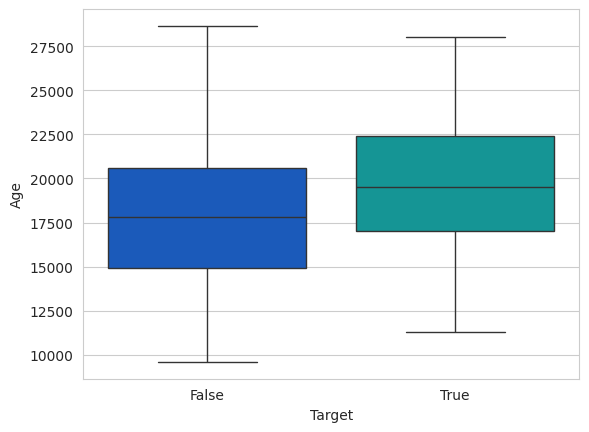

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


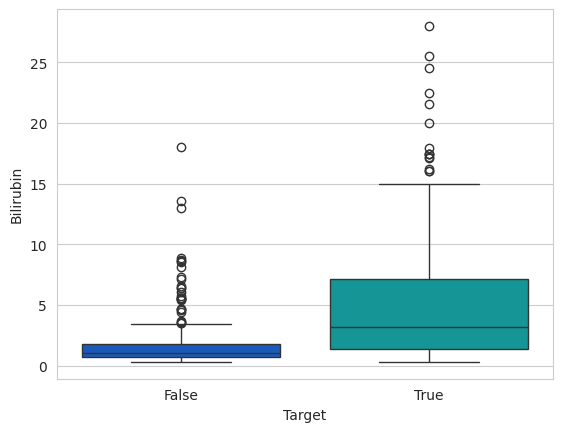

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


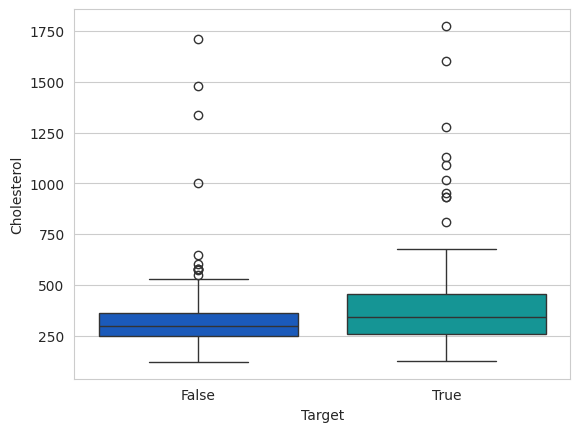

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


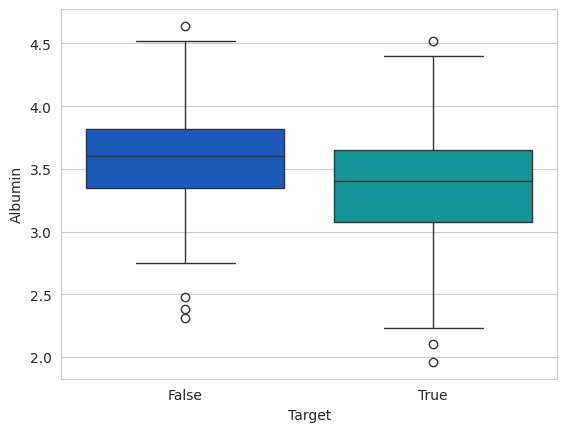

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


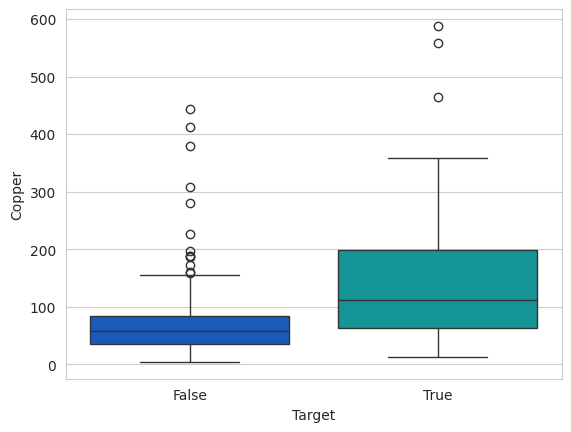

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


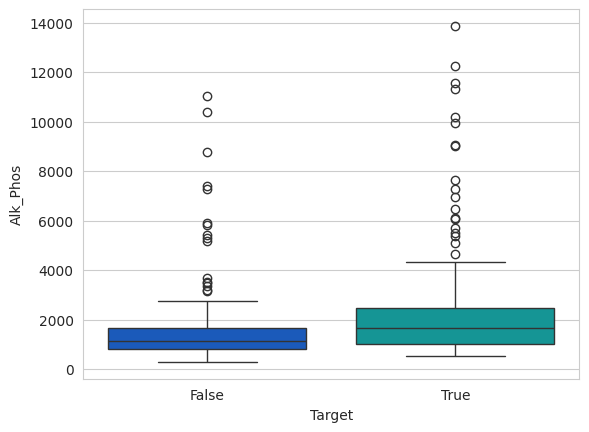

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


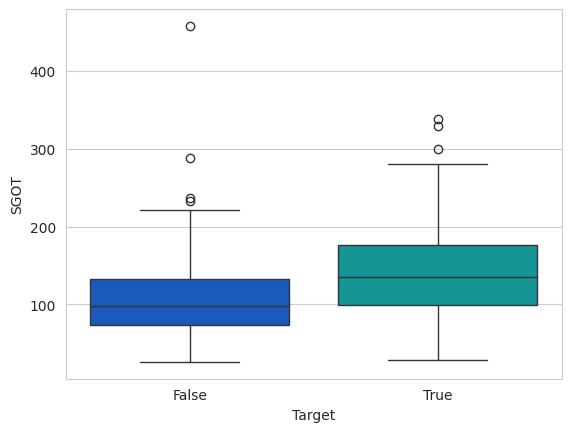

/tmp/ipykernel_331/768593111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, palette='winter')


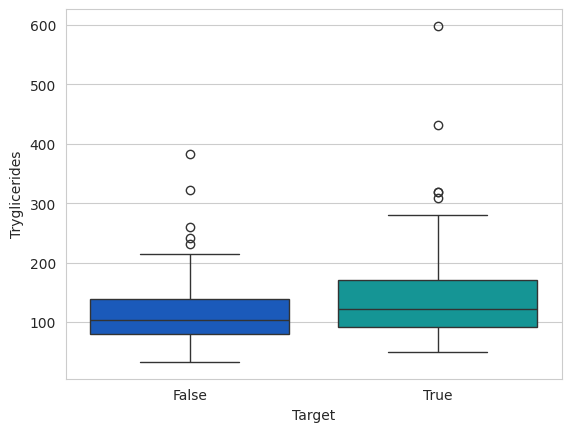

In [14]:
feature_list = list(X.columns[:10])  # first 10 features

for col in feature_list:
    sns.boxplot(x='Target', y=col, data=df, palette='winter')
    plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
import numpy as np

model = LogisticRegression(max_iter=1000)

# Identify rows with NaN values in X_train_scaled
nan_rows_mask = np.isnan(X_train_scaled).any(axis=1)

# Filter out rows with NaN values from X_train_scaled and corresponding y_train
X_train_cleaned = X_train_scaled[~nan_rows_mask]
y_train_cleaned = y_train[~nan_rows_mask]

model.fit(X_train_cleaned, y_train_cleaned)

LogisticRegression(max_iter=1000)

In [24]:
import numpy as np

# Identify rows with NaN values in X_test_scaled
nan_rows_mask_test = np.isnan(X_test_scaled).any(axis=1)

# Filter out rows with NaN values from X_test_scaled
X_test_cleaned = X_test_scaled[~nan_rows_mask_test]

y_pred = model.predict(X_test_cleaned)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Filter y_test to match the cleaned X_test_cleaned
y_test_cleaned = y_test[~nan_rows_mask_test]

print("Accuracy:", accuracy_score(y_test_cleaned, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test_cleaned, y_pred))

print("\nClassification Report:\n", classification_report(y_test_cleaned, y_pred))

Accuracy: 0.8888888888888888

Confusion Matrix:
 [[23  2]
 [ 3 17]]

Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.92      0.90        25
        True       0.89      0.85      0.87        20

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45

